# Supplement Sales Exploratory Data Analysis (EDA)

Exploratory data analysis of supplement sales data using Python, Pandas, Matplotlib, and Seaborn.

# 1. Project Overview

# Objective

The objective of this project is to explore supplement sales data and identify patterns in sales performance, product performance, category performance, performance in each platform, performance in each location, and product returns.


# Business Questions

This analysis aims to answer the following questions:

1. What does the overall revenue trend look like over time?
2. Which product categories generate the most revenue?
3. How does revenue break down by location and sales platform?
4. Which products are the best sellers, and which have the highest return rates?
5. Is there a relationship between discounting and sales volume?
6. Are there seasonal or monthly patterns in the data?
7. Which categories are most profitable after accounting for returns?


# Dataset

The dataset (`Supplement_Sales_Weekly_Expanded.csv`) contains weekly sales records for supplement products, including revenue, units sold, units returned, discount, price, category, location, and sales platform.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Data Overview and Understanding the Dataset

In [3]:
df = pd.read_csv("Supplement_Sales_Weekly_Expanded.csv")
df.shape

(4384, 10)

In [ ]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Monthly,Net
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,2020-01,4509.18
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,2020-01,5908.89
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,2020-01,2078.51
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,2020-01,2249.80
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,2020-01,5462.38


In [ ]:
df.info()

In [ ]:
df.isna().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


In [ ]:
df.describe(include="object")

,Date,Product Name,Category,Location,Platform
count,4384,4384,4384,4384,4384
unique,274,16,10,3,3
top,2020-01-06,Whey Protein,Vitamin,Canada,iHerb
freq,16,274,822,1507,1499


Summary of columns : shows how many unique categories, locations, and platforms exist in the data.

# Exploratory Data Analysis (EDA)

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

Convert the Date column to a proper datetime type.

In [8]:
sale_daily = df.groupby('Date').agg({
    "Revenue" : "sum", "Units Sold" : "sum" , "Units Returned" : "sum"
}).reset_index()

In [9]:
sale_daily.head()

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34


Aggregate revenue, units sold, and units returned by day to daily totals across all products.

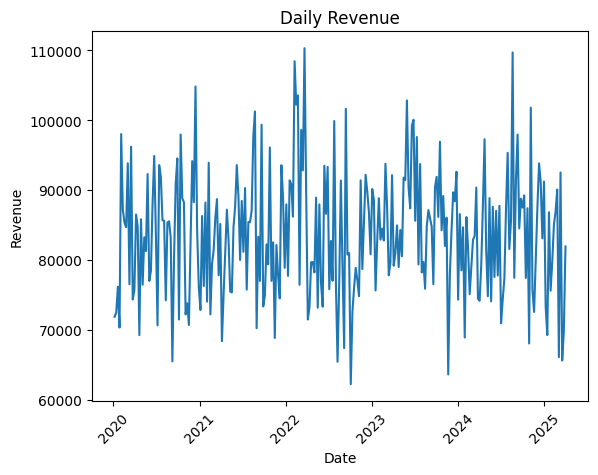

In [10]:
sns.lineplot(x="Date", y="Revenue" , data=sale_daily)
plt.title("Daily Revenue")
plt.xticks(rotation=45)
plt.show()

Finding: This line chart shows daily revenue from 2020 to 2025. The historical peak occured in 2022, exceeding $110,000. A secondary sharp spike approached in mid 2024 and early 2025. The lowest revenue drop occured in late 2022, dropping below $70,000.


In [31]:
category_rev = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
category_rev

Category
Vitamin        4300224.68
Mineral        4276107.99
Performance    2909702.18
Protein        2855492.09
Amino Acid     1464819.63
Omega          1451065.87
Fat Burner     1440900.05
Hydration      1411951.38
Herbal         1405700.79
Sleep Aid      1397315.79
Name: Revenue, dtype: float64

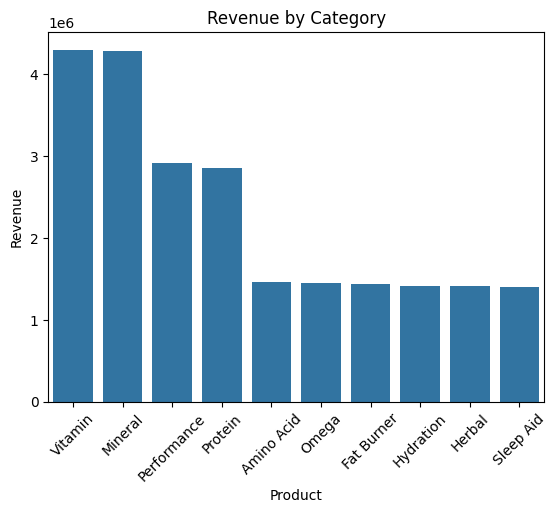

In [77]:
sns.barplot(x = category_rev.index, y = category_rev.values)
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.show()

Finding: This bar chart shows Revenue from each Category. Vitamin and Mineral are the dominant revenue generator, generating around $430,000 each. Performance and Protein each bringing around $290,000 in revenue. The standard performers including (Amino Acid, Omega, Fat Burner, Hydration, Herbal, and Sleep Aid) forming a flat baseline around $150,000.

In [12]:
location_platform = df.groupby(["Location", "Platform"])["Revenue"].sum().unstack()
location_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


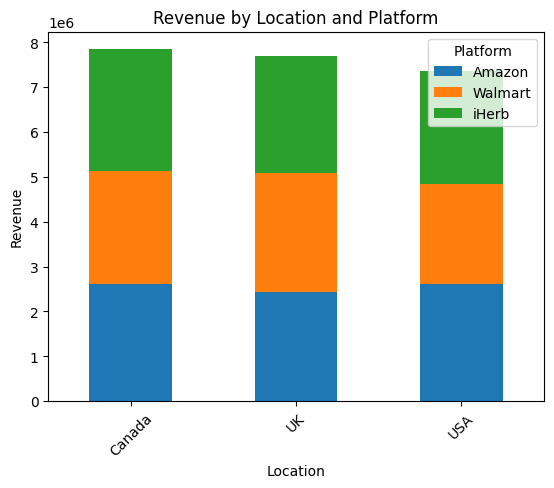

In [13]:
location_platform.plot(kind="bar", stacked=True)
plt.title("Revenue by Location and Platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Finding: Total Revenue evenly spread across all three locations. Platform contribution is almost identical across all three locations. No single platform or location dominates the overall revenue mix. This show a diversified market and sales strategy.

In [14]:
best_selling = df.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False)
top_seven = best_selling.head(7)
top_seven

Product Name
Biotin               1486798.62
Zinc                 1482546.95
Pre-Workout          1477183.78
BCAA                 1464819.63
Fish Oil             1451065.87
Green Tea Extract    1440900.05
Collagen Peptides    1433297.24
Name: Revenue, dtype: float64

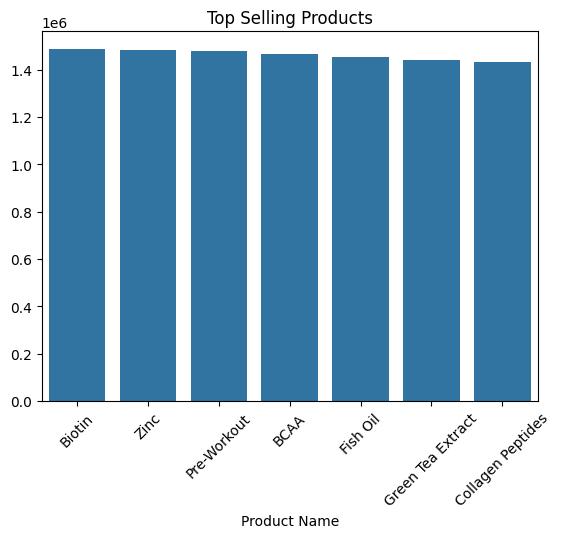

In [50]:
sns.barplot(x = top_seven.index, y = top_seven.values)
plt.title("Top Selling Products")
plt.xlabel("Product Name")
plt.xticks(rotation=45)
plt.show()

 Finding: This barchart shows Top Selling Products. All listed products are nearly identical in sales, with each generating around $140,000 in revenue. However, the top performers (Biotin, Zinc, and Pre Workout) lead slightly, each sitting under $150,000.

In [17]:
df["Return Rate"] = (df["Units Returned"] / df["Units Sold"].replace(0, pd.NA)).astype(float)

In [19]:
product_return_rate = df.groupby("Product Name")["Return Rate"].mean().sort_values(ascending=False)
product_return_rate
top_seven_return_rate = product_return_rate.head(7)

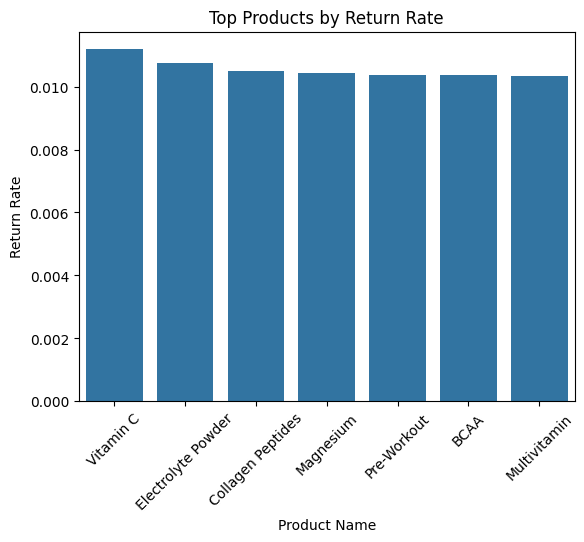

In [20]:
sns.barplot(x = top_seven_return_rate.index, y = top_seven_return_rate.values)
plt.title("Top Products by Return Rate")
plt.xlabel("Product Name")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.show()


Finding: Return rates across all products are exceptionally low remaining aroung 1%.

In [22]:
df['Monthly'] = df["Date"].dt.to_period('M')
monthly = df.groupby('Monthly').agg({
    "Revenue" : "sum", "Units Sold" : "sum" , "Units Returned" : "sum", "Discount" : "mean"}).reset_index()
monthly.head()

,Monthly,Revenue,Units Sold,Units Returned,Discount
0,2020-01,290723.89,9547,101,0.120313
1,2020-02,355213.26,9493,91,0.128125
2,2020-03,416547.17,12145,123,0.111375
3,2020-04,326287.92,9605,91,0.138281
4,2020-05,333210.99,9557,90,0.119375


In [23]:
monthly['Monthly'] = monthly["Monthly"].astype(str)

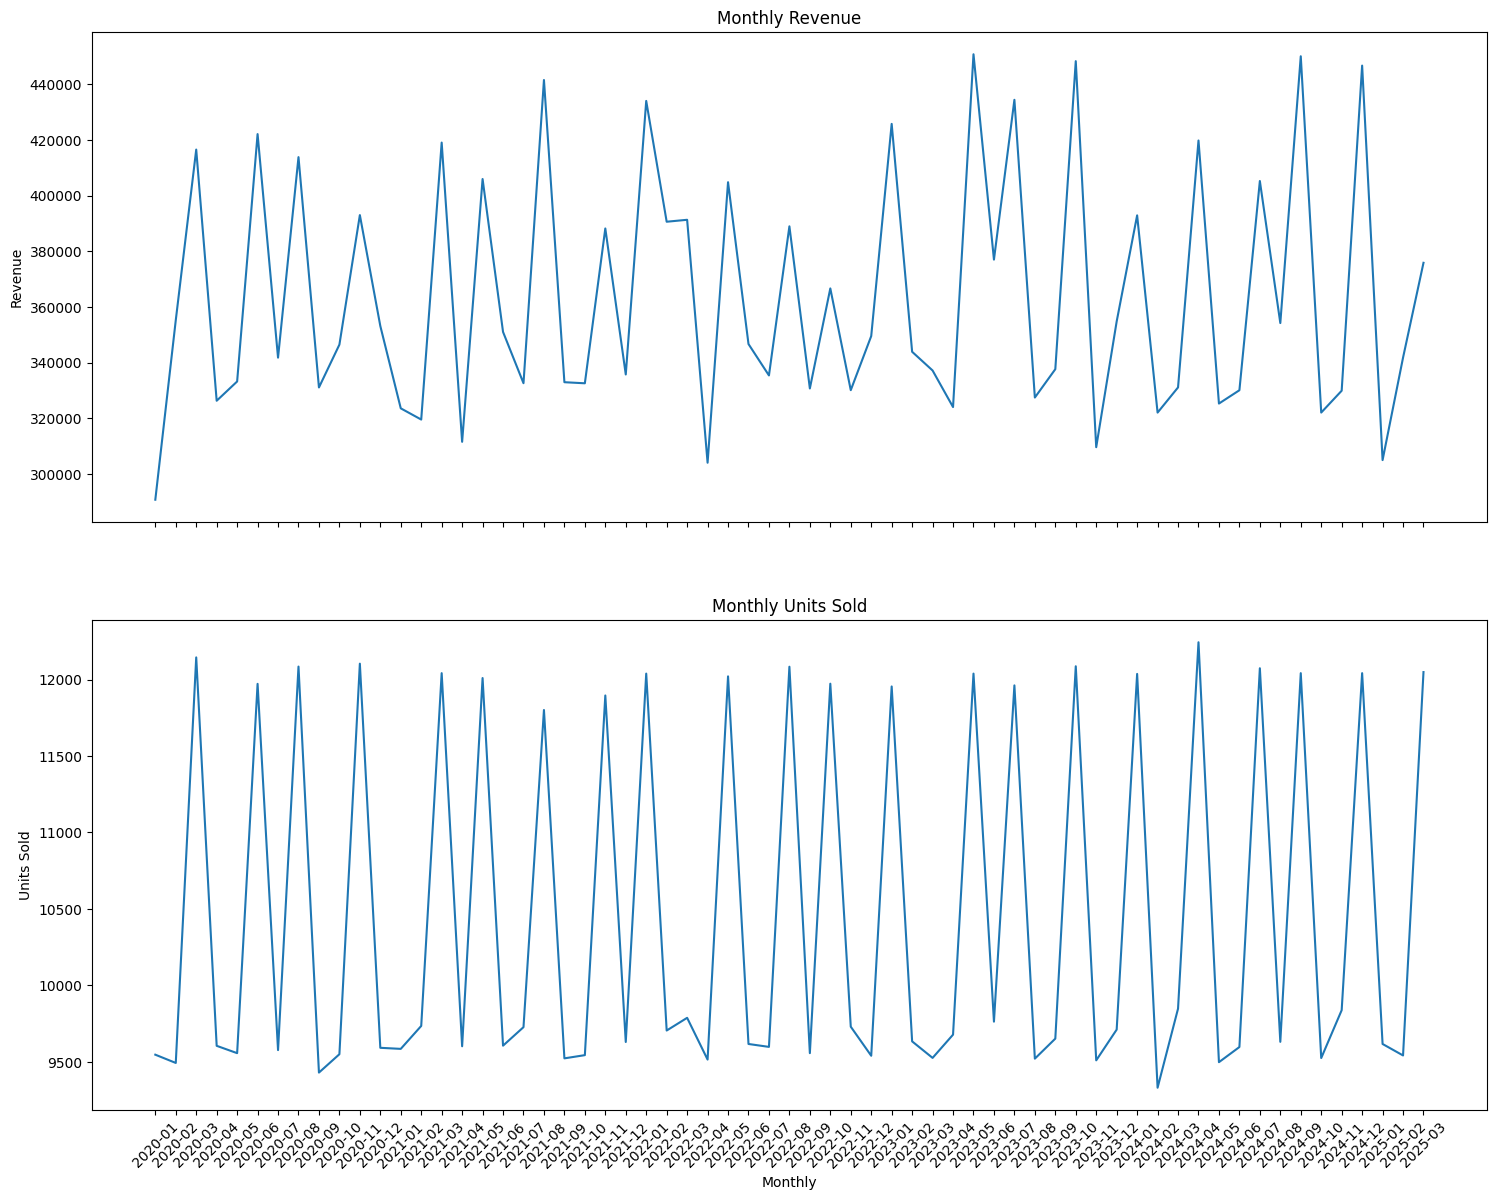

In [70]:
fig, axes = plt.subplots(2,1, sharex=True, figsize=(18, 14))

sns.lineplot(x="Monthly", y="Revenue" , data=monthly, ax=axes[0])
axes[0].set_title("Monthly Revenue")
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(x="Monthly", y="Units Sold" , data=monthly, ax=axes[1])
axes[1].set_title("Monthly Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

Finding: Units sold has a predictable and repeating pattern. Sales bounce between a low baseline of 9500 units and high baseline arount 12000 units.

While monthly revenue generall allign with sales volume, it shoes a greater overall fluctuation, ranging from a low $290,000 to peak months exceeding $440,000.

## Profitability by Category


In [25]:
df['Net'] = df['Revenue'] - df['Units Returned']*df['Price']
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Monthly,Net
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,2020-01,4509.18
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,2020-01,5908.89
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,2020-01,2078.51
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,2020-01,2249.80
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,2020-01,5462.38


In [26]:
profit = df.groupby("Category")['Net'].sum().sort_values(ascending=False)
profit.head()

Category
Vitamin        4255337.22
Mineral        4233108.50
Performance    2879997.43
Protein        2827040.48
Amino Acid     1449514.18
Name: Net, dtype: float64

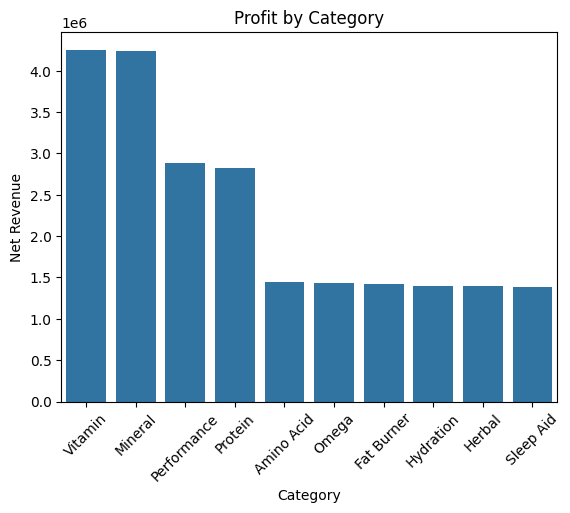

In [27]:
sns.barplot(x = profit.index, y = profit.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.show()



Finding: 

Top Profit Generator: Vitamin and Mineral generate the highest net revenue or profit, leading the chart at $420,000 to $430,000 each.

Performance and Protein form a strong secondary tier, generati around $280,000 in profit.

The overall shape and category ranking mirror the revene distribution closely, showing consistent profit margins across product lines.

# Conclusion

## Overall Conclusion
The business shows a stable, diversified sales structure: revenue is spread evenly across locations and platforms, product returns are negligible, and profitability tracks revenue closely because there is little return driven erosion. Vitamin and Mineral products are the primary growth and profit driver and warrant continued investment (inventory priority, marketing focus), while the mid tier categories (Performance, Protein) represent a secondary opportunity. 

## Key Findings
- **Revenue trend and seasonality:** Daily revenue from 2020 to 2025 shows no steady upward or downward trend but does show clear volatility, peaking above $110,000 in 2022 and dipping below $70,000 in late 2022, with a secondary spike in mid 2024/early 2025. At the monthly level, units sold follow a repeating cycle pattern roughly 9,500 to 12,000 units, pointing to a recurring seasonal demand cycle
- **Category, location, and platform performance:** Vitamin and Mineral is the clear revenue and profit leader ($420,000-$430,000), with Performance and Protein forming a secondary tier ($280,000-$290,000). The remaining categories (Amino Acid, Omega, Fat Burner, Hydration, Herbal, Sleep Aid) form a flat baseline around $150,000. Revenue is evenly split across all three locations and sales platforms, with no single location or platform dominating - indicating a well-diversified sales strategy rather than dependence on one channel.
- **Best sellers:** Top-selling products (Biotin, Zinc, Pre Workout) are only marginally ahead of the rest, each generating close to $140,000-$150,000 in revenue, so the product mix is fairly balanced rather than driven by a few standout SKUs. Return rates are low across the board around 1%, so returns are not a meaningful drag on any particular product's performance.
- **Profitability:** Since return rates are uniformly low (~1%), category profitability closely mirrors category revenue - Vitamin and Mineral remains the top profit generator, followed by Performance and Protein, confirming that returns have minimal impact on overall category profit margins.


